# Titanic Survival Prediction Using Machine Learning

## CodSoft Machine Learning Internship – Task 1

## Objective

The objective of this project is to build a Machine Learning model that predicts whether a passenger survived the Titanic disaster based on features such as age, gender, passenger class, fare, and family information.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
df = pd.read_csv("Dataset/Titanic-Dataset.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [4]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## Data Cleaning

The dataset contains missing values in the **Age**, **Cabin**, and **Embarked** columns.

- Missing Age values are replaced with the median.
- Missing Embarked values are replaced with the most frequent value.
- The Cabin column is removed because it contains too many missing values.

In [5]:
# Fill missing Age values with the median
df["Age"] = df["Age"].fillna(df["Age"].median())

# Fill missing Embarked values with the most frequent value
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Drop the Cabin column
df = df.drop("Cabin", axis=1)

# Check missing values again
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

## Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps us understand the dataset through visualizations. In this project, we analyze:

- Survival Distribution
- Survival Rate by Gender
- Age Distribution

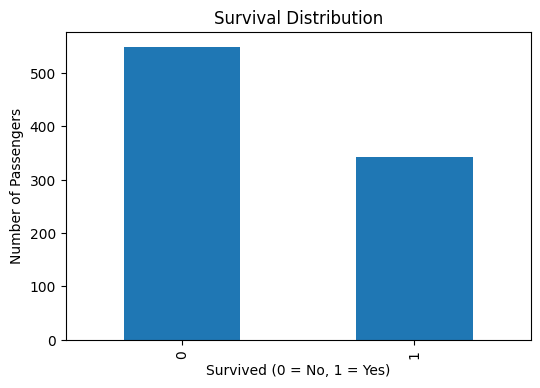

In [7]:
plt.figure(figsize=(6,4))

df["Survived"].value_counts().plot(kind="bar")

plt.title("Survival Distribution")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")

plt.savefig("screenshots/survival_distribution.png")

plt.show()

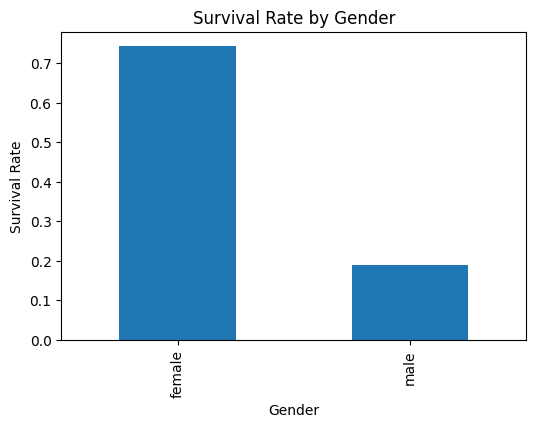

In [8]:
plt.figure(figsize=(6,4))

df.groupby("Sex")["Survived"].mean().plot(kind="bar")

plt.title("Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate")

plt.savefig("screenshots/survival_by_gender.png")

plt.show()

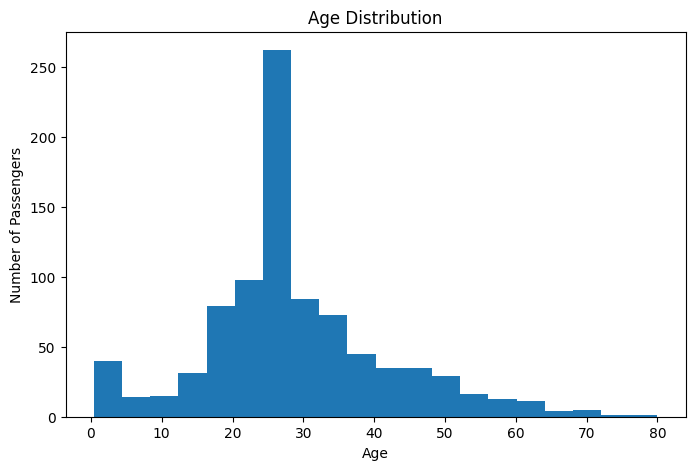

In [9]:
plt.figure(figsize=(8,5))

plt.hist(df["Age"], bins=20)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.savefig("screenshots/age_distribution.png")

plt.show()

## Feature Engineering

Machine learning models require numerical data for training. In this step:

- Unnecessary columns are removed.
- Categorical features are converted into numerical values.
- The dataset is prepared for model training.

In [10]:
df = df.drop(["PassengerId", "Name", "Ticket"], axis=1)

df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [11]:
encoder = LabelEncoder()

df["Sex"] = encoder.fit_transform(df["Sex"])

df["Embarked"] = encoder.fit_transform(df["Embarked"])

df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


In [12]:
X = df.drop("Survived", axis=1)

y = df["Survived"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (891, 7)
Target Shape: (891,)


## Train-Test Split

The dataset is divided into training and testing sets using an 80:20 ratio. The training set is used to train the machine learning model, while the testing set is used to evaluate its performance on unseen data.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (712, 7)
Testing Data Shape: (179, 7)


## Model Training

In this step, a Random Forest Classifier is trained using the training dataset. The model learns patterns from the data to predict whether a passenger survived or not.

In [14]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


## Model Evaluation

After training the model, predictions are made on the testing dataset. The performance is evaluated using Accuracy Score, Confusion Matrix, and Classification Report.

In [15]:
predictions = model.predict(X_test)

predictions[:10]

array([0, 0, 0, 1, 0, 1, 1, 0, 1, 1])

In [16]:
accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 0.8212290502793296


In [17]:
cm = confusion_matrix(y_test, predictions)

print(cm)

[[92 13]
 [19 55]]


In [18]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.83      0.88      0.85       105
           1       0.81      0.74      0.77        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



## Model Results Visualization

The trained model is evaluated using a confusion matrix and feature importance. These visualizations help us understand the model's performance and identify which features contribute most to the predictions.

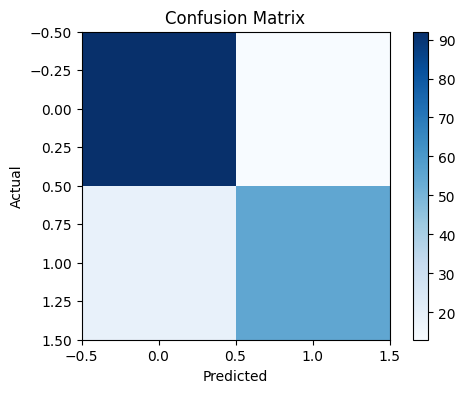

In [19]:
plt.figure(figsize=(6,4))

plt.imshow(cm, cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.colorbar()

plt.savefig("screenshots/confusion_matrix.png")

plt.show()

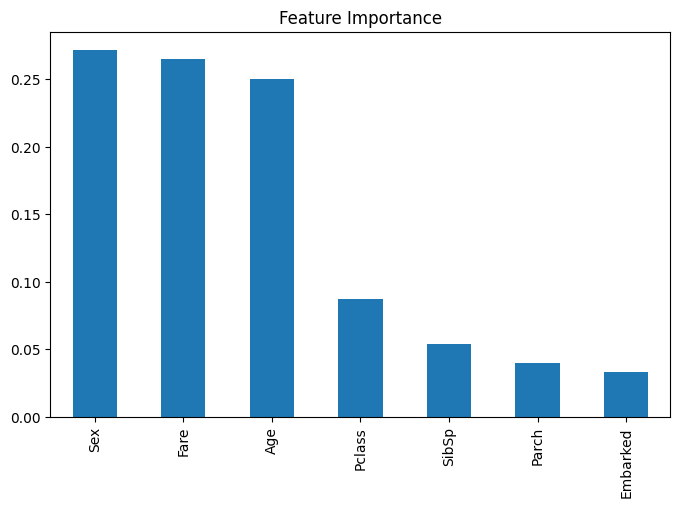

In [20]:
feature_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(8,5))

feature_importance.plot(kind="bar")

plt.title("Feature Importance")

plt.savefig("screenshots/feature_importance.png")

plt.show()

# Conclusion

A Random Forest Classifier was successfully developed to predict Titanic passenger survival.

### Workflow Completed

- Data Loading
- Data Cleaning
- Exploratory Data Analysis
- Feature Engineering
- Model Training
- Model Evaluation
- Result Visualization

### Final Model Accuracy

**82.12%**

The model demonstrates good predictive performance and successfully classifies passenger survival using features such as age, passenger class, fare, family information, gender, and embarkation port.